In [1]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to sys.path:/", repo_root)
from fixedincomelib import *

print("Fixed Income Library is loaded.")

Added to sys.path:/ /Users/leo/Leo/Risk_topic/FRE-GT-9743-Assignment-8
Fixed Income Library is loaded.


# 1. SABR Conversion

The SABR model is a stochastic volatility model developed by Hagan et al. The dynamics of the forward rate \(F(t)\) are:

$
dF(t)=\sigma(t)F^\beta(t)dW_1(t)
$

$
d\sigma(t)=\nu\sigma(t)dW_2(t)
$

$
dW_1 dW_2 = \rho dt
$

with initial conditions:

$
F(0)=F_0
$

$
\sigma(0)=\alpha
$

---

Using asymptotic expansion techniques, the equivalent Black volatility can be written as:

$
\sigma_{LN}^{B} =
\frac{\alpha}{(FK)^{(1-\beta)/2}}
\frac{z}{x(z)}
\omega_1
\left(1+\omega_2 T + \cdots \right)
$

---

### Definitions

$
z =
\frac{\nu}{\alpha}
(FK)^{(1-\beta)/2}
\log(F/K)
$

$
x(z) =
\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)
$

$
\omega_1 =
1+
\frac{(1-\beta)^2}{24}\log^2(F/K)
+
\frac{(1-\beta)^4}{1920}\log^4(F/K)
+\cdots
$

$
\omega_2 =
\frac{(1-\beta)^2}{24}
\frac{\alpha^2}{(FK)^{1-\beta}}
+
\frac{1}{4}
\frac{\alpha\beta\rho\nu}{(FK)^{(1-\beta)/2}}
+
\frac{2-3\rho^2}{24}\nu^2
$

---

## Hagan's formula expansion around ATM

Notice that:

$
\frac{z}{x}=
\frac{z}
{\log\left(
\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}
\right)}
$

This expression becomes indeterminate at \(z=0\), which corresponds to:

$
K=F
$

For small $z$, we use a Taylor expansion:

$
\frac{z}{x}
\approx 1
-\frac{1}{2}\rho z +
\left(
-\frac{1}{4}\rho^2+\frac{1}{6}
\right)z^2 -
\left(
\frac{1}{4}\rho^2-\frac{5}{24}
\right)\rho z^3+
\left(
-\frac{5}{16}\rho^4
+\frac{1}{3}\rho^2
-\frac{17}{360}
\right)z^4-
\left(
\frac{7}{16}\rho^4
-\frac{55}{96}\rho^2
+\frac{37}{240}
\right)\rho z^5
$

This expansion is typically sufficient when:

$
|z|<0.01
$

---

When the strike is very close to zero or very large, the density derived from the equivalent Black volatility may become negative or unstable. This motivates corrections to the wings of the Hagan expansion.

According to the readings above, please complete the functions referenced in `sabr.py`.

You may use the API provided above to implement both the volatility and risk functions. After that, run the code blocks below.

In [2]:
# utilities
def display_res(input_dict: Dict[SimpleMetrics, float]):
    display({k.to_string(): v for k, v in input_dict.items()})

In [3]:
### hagan's classic formula
alpha = 0.11
beta = 0.6
nu = 0.5
rho = 0.5
shift = 0.04
forward = 0.04
strike = 0.042
tte = 0.5

res_imp_log_normal_vol = qfEuropeanOptionSABRLogNormalSigma(
    forward, strike, tte, alpha, beta, rho, nu, shift, True
)
display_res(res_imp_log_normal_vol)

{'implied_log_normal_vol': np.float64(0.3075362081997875),
 'd_ln_sigma_d_alpha': np.float64(9.051526234839306),
 'd_ln_sigma_d_beta': np.float64(-2.4947233069049926),
 'd_ln_sigma_d_rho': np.float64(0.015606211717868926),
 'd_ln_sigma_d_nu': np.float64(0.0578448084635778),
 'd_ln_sigma_d_forward': np.float64(-7.805814513634762),
 'd_ln_sigma_d_strike': np.float64(2.7585122775347988),
 'd_ln_sigma_d_tte': 0.024590290064112556}

In [4]:
eps = 1e-6
vol_base = qfEuropeanOptionSABRLogNormalSigma(forward, strike, tte, alpha,     beta, rho, nu, shift, False)
vol_up   = qfEuropeanOptionSABRLogNormalSigma(forward, strike, tte, alpha+eps, beta, rho, nu, shift, False)

print("base:", vol_base[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL])
print("up:  ", vol_up[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL])

numerical_dalpha = (
    vol_up[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL] 
    - vol_base[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL]
) / eps / vol_base[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL]
print(numerical_dalpha)

base: 0.3075362081997875
up:   0.3075389918720121
9.05152678089575


# 2. Detection of Negative Density

The parameters set is:

In [5]:
# lower wing parameters
alpha = 0.0512
beta = 0.5
nu = 0.322
rho = -9.5/100
shift = 0.0
forward = 3.54/100
tte = 10

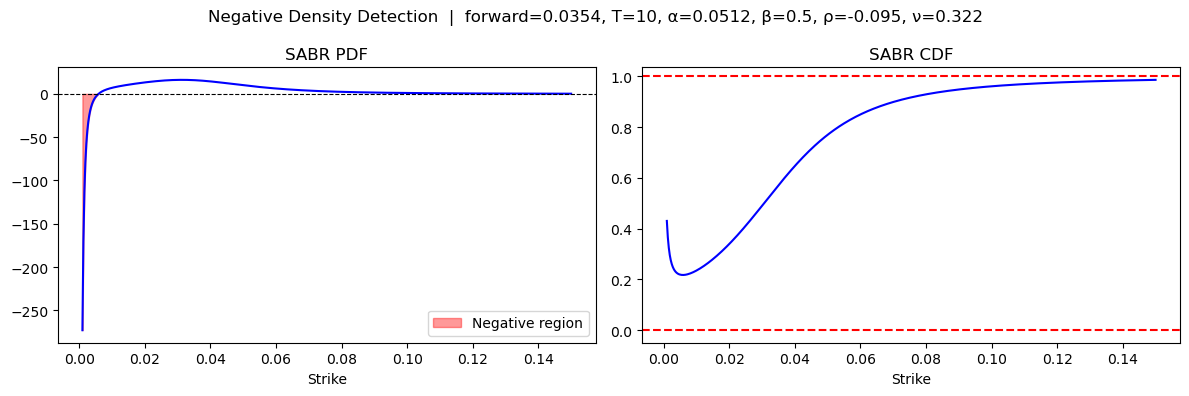

Negative density detected: K ∈ [0.0010, 0.0058]
Number of strikes affected: 17 / 500
Min pdf value: -272.9576


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def detect_negative_density(
    forward, tte, alpha, beta, rho, nu,
    shift=0.0, n_strikes=500, lower=0.001, upper=0.15
):
    strikes = np.linspace(lower, upper, n_strikes)
    pdf, cdf = SABRAnalytics.pdf_and_cdf(
        forward, tte, alpha, beta, rho, nu, strikes, shift
    )
    neg_mask = pdf < 0

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(strikes, pdf, 'b-')
    axes[0].fill_between(strikes, pdf, where=neg_mask, color='red', alpha=0.4, label='Negative region')
    axes[0].axhline(0, color='k', linestyle='--', linewidth=0.8)
    axes[0].set_title('SABR PDF')
    axes[0].set_xlabel('Strike')
    axes[0].legend()

    axes[1].plot(strikes, cdf, 'b-')
    axes[1].axhline(0, color='r', linestyle='--')
    axes[1].axhline(1, color='r', linestyle='--')
    axes[1].set_title('SABR CDF')
    axes[1].set_xlabel('Strike')

    plt.suptitle(f'Negative Density Detection  |  forward={forward}, T={tte}, '
                f'α={alpha}, β={beta}, ρ={rho}, ν={nu}')
    plt.tight_layout()
    plt.show()

    if neg_mask.any():
        neg_strikes = strikes[neg_mask]
        print(f"Negative density detected: K ∈ [{neg_strikes[0]:.4f}, {neg_strikes[-1]:.4f}]")
        print(f"Number of strikes affected: {neg_mask.sum()} / {n_strikes}")
        print(f"Min pdf value: {pdf[neg_mask].min():.4f}")
        return neg_strikes
    else:
        print("No negative density detected")
        return None


neg_strikes = detect_negative_density(forward, tte, alpha, beta, rho, nu, shift)

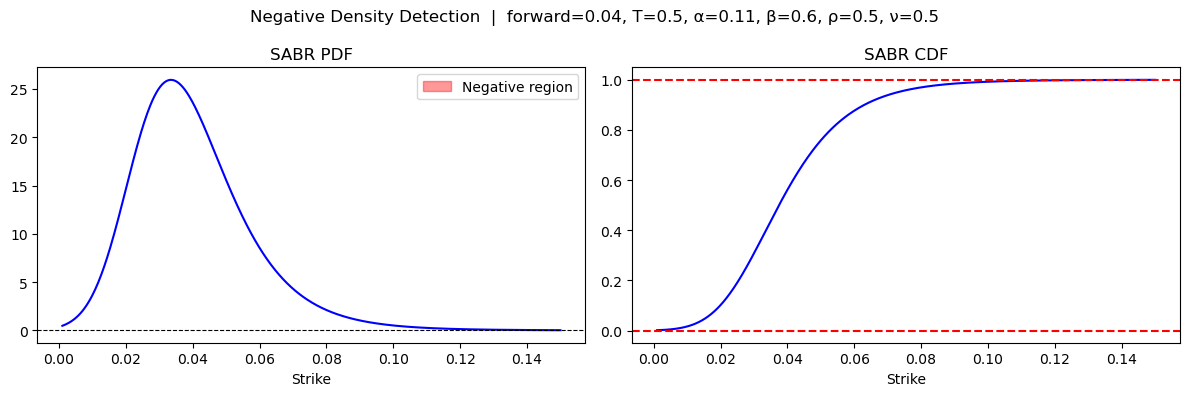

No negative density detected


In [7]:
detect_negative_density(
    forward=0.04, tte=0.5, alpha=0.11,
    beta=0.6, rho=0.5, nu=0.5, shift=0.04
)

# 3. SABR Simulation and Density

For bump-and-revaluation calculations, please use the functions provided in `european_options.py`.

If an analytical solution is preferred, the corresponding implementation can be found in `sabr.py`.

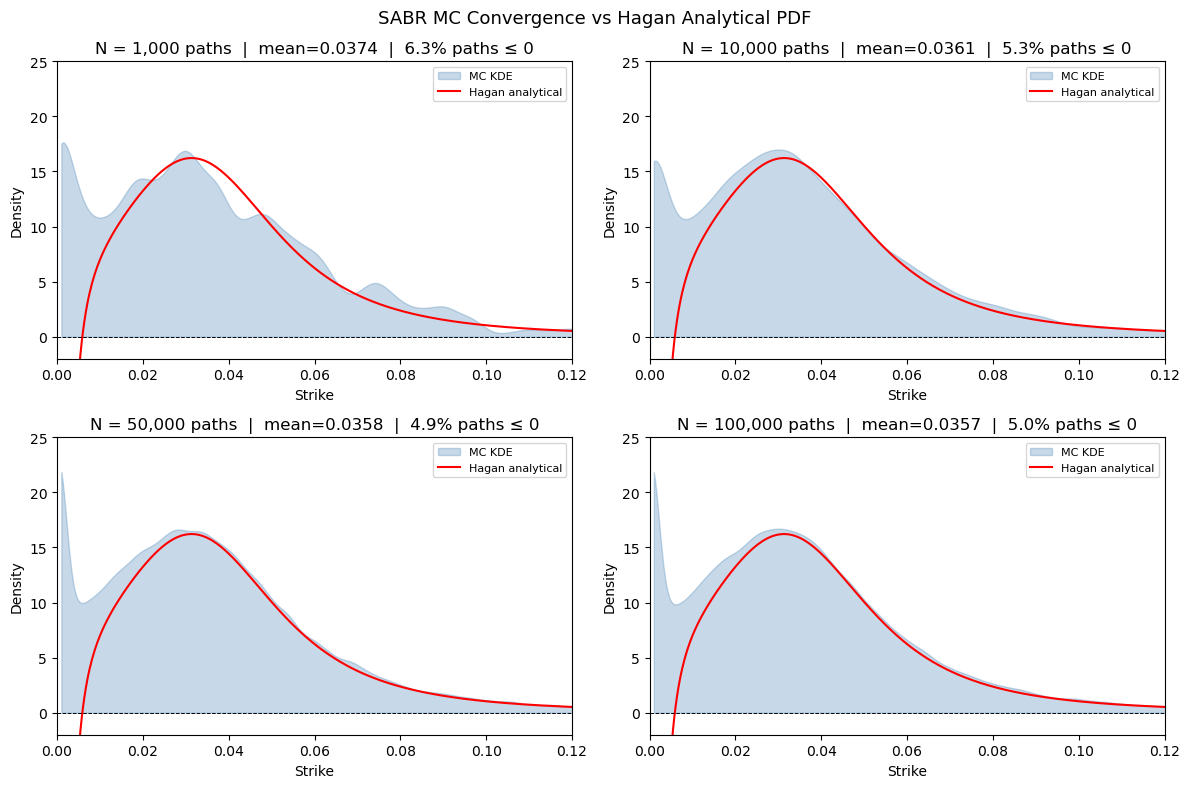


Call price convergence (K=forward):
N paths          MC price  Hagan price       diff
------------------------------------------------
1000             0.014038     0.012695   0.001342
10000            0.012396     0.012695  -0.000299
50000            0.011958     0.012695  -0.000738
100000           0.011881     0.012695  -0.000815


In [8]:
from scipy.stats import gaussian_kde

alpha   = 0.0512
beta    = 0.5
nu      = 0.322
rho     = -9.5/100
shift   = 0.0
forward = 3.54/100
tte     = 10
n_steps = 252 * tte

def simulate_sabr(n_paths, n_steps, forward, alpha, beta, nu, rho, tte, seed=42):
    dt  = tte / n_steps
    rng = np.random.default_rng(seed)
    Z1  = rng.standard_normal((n_steps, n_paths))
    Z2  = rho * Z1 + np.sqrt(1 - rho**2) * rng.standard_normal((n_steps, n_paths))
    F = np.full(n_paths, forward)
    s = np.full(n_paths, alpha)
    for i in range(n_steps):
        F_pos = np.maximum(F, 1e-10)
        F     = F_pos + s * F_pos**beta * np.sqrt(dt) * Z1[i]
        s     = np.maximum(s + nu * s * np.sqrt(dt) * Z2[i], 1e-10)
    return F

strikes    = np.linspace(0.001, 0.15, 500)
pdf_hagan, _ = SABRAnalytics.pdf_and_cdf(
    forward, tte, alpha, beta, rho, nu, strikes, shift
)

path_counts = [1_000, 10_000, 50_000, 100_000]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, n_paths in zip(axes, path_counts):
    F     = simulate_sabr(n_paths, n_steps, forward, alpha, beta, nu, rho, tte)
    F_pos = F[F > 0]

    kde = gaussian_kde(F_pos, bw_method=0.05)
    x   = np.linspace(0.001, 0.15, 500)

    ax.fill_between(x, kde(x), alpha=0.3, color='steelblue', label='MC KDE')
    ax.plot(strikes, pdf_hagan, 'r-', linewidth=1.5, label='Hagan analytical')
    ax.axhline(0, color='k', linestyle='--', linewidth=0.7)
    ax.set_title(f'N = {n_paths:,} paths  |  mean={F.mean():.4f}  |  {(F<=0).mean()*100:.1f}% paths ≤ 0')
    ax.set_xlim(0, 0.12)
    ax.set_ylim(-2, 25)
    ax.set_xlabel('Strike')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('SABR MC Convergence vs Hagan Analytical PDF', fontsize=13)
plt.tight_layout()
plt.show()

print("\nCall price convergence (K=forward):")
print(f"{'N paths':<12} {'MC price':>12} {'Hagan price':>12} {'diff':>10}")
print("-" * 48)

ln_vol_atm = qfEuropeanOptionSABRLogNormalSigma(
    forward, forward, tte, alpha, beta, rho, nu, shift, False
)[SimpleMetrics.IMPLIED_LOG_NORMAL_VOL]
hagan_price = EuropeanOptionAnalytics.european_option_log_normal(
    forward, forward, tte, ln_vol_atm, CallOrPut.CALL
)[SimpleMetrics.PV]

for n_paths in path_counts:
    F  = simulate_sabr(n_paths, n_steps, forward, alpha, beta, nu, rho, tte)
    mc_price = np.maximum(F - forward, 0).mean()
    print(f"{n_paths:<12} {mc_price:>12.6f} {hagan_price:>12.6f} {mc_price - hagan_price:>10.6f}")

# 4. Quantile Map


alpha1 = 0.057644
alpha2 = 0.053585
Building quantile maps from SABR CDF...
Quantile maps built.

Spread option price: 0.00000129
Standard error:      0.00000080
95% CI:              [-0.00000028, 0.00000286]

N paths                 Price        Std Error
----------------------------------------------
1000               0.00000000       0.00000000
10000              0.00000010       0.00000010
50000              0.00000008       0.00000006
100000             0.00000292       0.00000283


/var/folders/sq/lfy388r96hz2nykcnsnb56bh0000gn/T/ipykernel_34363/1150680207.py:78: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sobol.random(n_paths)


500000             0.00000129       0.00000080


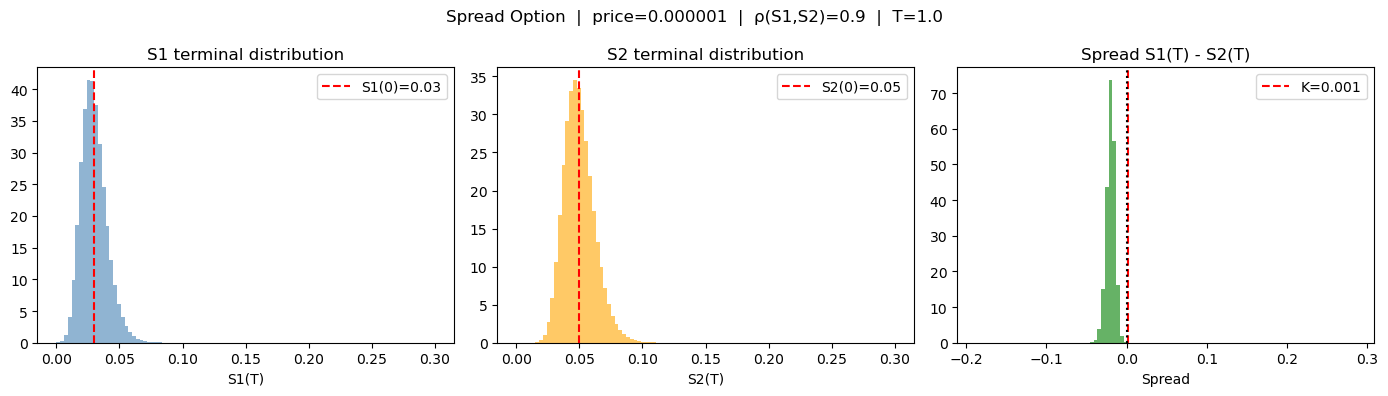

In [18]:
from scipy.interpolate import CubicSpline
from scipy.stats import norm
from scipy.stats.qmc import Sobol

# ── Parameters ───────────────────────────────────────────────────────────────
S1_0, sigma1_n, beta1, nu1, rho1 = 0.03, 0.01, 0.5, 0.2, 0.25
S2_0, sigma2_n, beta2, nu2, rho2 = 0.05, 0.012, 0.5, 0.15, 0.45
rho_12 = 0.9
K      = 0.001
tte    = 1.0
shift  = 0.0

# ── Step 1: back out alpha from normal ATM vol ───────────────────────────────
alpha1 = SABRAnalytics.alpha_from_atm_normal_sigma(
    S1_0, tte, sigma1_n, beta1, rho1, nu1, shift
)[SabrMetrics.ALPHA]

alpha2 = SABRAnalytics.alpha_from_atm_normal_sigma(
    S2_0, tte, sigma2_n, beta2, rho2, nu2, shift
)[SabrMetrics.ALPHA]

print(f"alpha1 = {alpha1:.6f}")
print(f"alpha2 = {alpha2:.6f}")

# ── Step 2: build interpolator from SABR CDF (Breeden-Litzenberger) ──────────
def build_quantile_map(forward, tte, alpha, beta, rho, nu, shift=0.0,
                        n_strikes=2000, lower=1e-4, upper=0.3):
    """
    Following the PDF:
      - Pick grid {xi}
      - Compute ui = F_X(xi) via SABR CDF (bump-reval)
      - Compute yi = Phi^{-1}(ui)
      - Build cubic spline I such that I(yi) = xi
    """
    # pick grid {xi}
    strikes = np.linspace(lower, upper, n_strikes)

    # compute ui = F_X(xi) via Breeden-Litzenberger
    _, cdf = SABRAnalytics.pdf_and_cdf(
        forward, tte, alpha, beta, rho, nu, strikes, shift
    )

    # ensure CDF is valid and monotone
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)
    for i in range(1, len(cdf)):
        cdf[i] = max(cdf[i], cdf[i-1] + 1e-10)

    # compute yi = Phi^{-1}(ui)
    y = norm.ppf(cdf)

    # build cubic spline I: y -> x
    spline = CubicSpline(y, strikes, extrapolate=False)
    y_min, y_max = y[0], y[-1]
    x_min, x_max = strikes[0], strikes[-1]

    def interpolator(y_vals):
        y_vals = np.clip(y_vals, y_min, y_max)
        return np.clip(spline(y_vals), x_min, x_max)
    return interpolator

print("Building quantile maps from SABR CDF...")
I1 = build_quantile_map(S1_0, tte, alpha1, beta1, rho1, nu1, shift)
I2 = build_quantile_map(S2_0, tte, alpha2, beta2, rho2, nu2, shift)
print("Quantile maps built.")

# ── Step 3: price spread option ──────────────────────────────────────────────
def price_spread_option(I1, I2, rho_12, K, n_paths=500_000):
    """
    Price E[(S1(T) - S2(T) - K)^+] strictly following PDF pipeline:
      (i)   s ~ U[0,1]^2 via Sobol
      (ii)  yhat = Phi^{-1}(s)
      (iii) y = B @ yhat, B = Cholesky([[1, rho],[rho, 1]])
      (iv)  xi = Ii(yi)
      (v)   E[G] ≈ (1/N) sum G(x1, x2)
    """
    # (i) Sobol samples
    sobol   = Sobol(d=2, scramble=True, seed=42)
    samples = sobol.random(n_paths)

    # (ii) independent normals: yhat = Phi^{-1}(s)
    yhat = norm.ppf(np.clip(samples, 1e-6, 1 - 1e-6))

    # (iii) correlate: y = B @ yhat
    corr = np.array([[1.0, rho_12], [rho_12, 1.0]])
    B    = np.linalg.cholesky(corr)
    y    = yhat @ B.T

    # (iv) apply interpolators component-wise
    S1 = I1(y[:, 0])
    S2 = I2(y[:, 1])

    # (v) evaluate payoff
    payoff = np.maximum(S1 - S2 - K, 0)
    price  = payoff.mean()
    se     = payoff.std() / np.sqrt(n_paths)
    return price, se, S1, S2

price, se, S1, S2 = price_spread_option(I1, I2, rho_12, K)
print(f"\nSpread option price: {price:.8f}")
print(f"Standard error:      {se:.8f}")
print(f"95% CI:              [{price - 1.96*se:.8f}, {price + 1.96*se:.8f}]")

# ── Step 4: convergence table ────────────────────────────────────────────────
print(f"\n{'N paths':<12} {'Price':>16} {'Std Error':>16}")
print("-" * 46)
for n in [1_000, 10_000, 50_000, 100_000, 500_000]:
    p, s, _, _ = price_spread_option(I1, I2, rho_12, K, n_paths=n)
    print(f"{n:<12} {p:>16.8f} {s:>16.8f}")

# ── Step 5: plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(S1, bins=100, density=True, alpha=0.6, color='steelblue')
axes[0].axvline(S1_0, color='r', linestyle='--', label=f'S1(0)={S1_0}')
axes[0].set_title('S1 terminal distribution')
axes[0].set_xlabel('S1(T)')
axes[0].legend()

axes[1].hist(S2, bins=100, density=True, alpha=0.6, color='orange')
axes[1].axvline(S2_0, color='r', linestyle='--', label=f'S2(0)={S2_0}')
axes[1].set_title('S2 terminal distribution')
axes[1].set_xlabel('S2(T)')
axes[1].legend()

spread = S1 - S2
axes[2].hist(spread, bins=100, density=True, alpha=0.6, color='green')
axes[2].axvline(K, color='r', linestyle='--', label=f'K={K}')
axes[2].axvline(0, color='k', linestyle=':')
axes[2].set_title('Spread S1(T) - S2(T)')
axes[2].set_xlabel('Spread')
axes[2].legend()

plt.suptitle(f'Spread Option  |  price={price:.6f}  |  ρ(S1,S2)={rho_12}  |  T={tte}')
plt.tight_layout()
plt.show()

Bonus question:  we can simulate both S1 and S2 paths simultaneously by discretizing their SDEs with correlated Brownians, then compute the payoff directly. The two prices should agree within Monte Carlo noise. Any systematic gap comes from the marginal-then-couple approximation in the quantile map — it correctly captures each asset's marginal distribution but approximates the joint dependence using only the linear correlation rho_12, which may miss higher-order joint dynamics.